# 💊 HealthEat 경구약제 검출 — EDA ①: 도메인 앵커(대회 기본 데이터)

> **코드잇 AI 부트캠프 · 초급 프로젝트 3팀 · Model Architect(이형기/LHK)**
> Object Detection · 이미지당 0~4알 · 지표 **mAP@[0.75:0.95]** · GitHub freeze **2026-07-13 19:00**

**이 노트북의 범위:** 출처별 3분할 EDA 중 **(1) 대회 기본 데이터** — 유일하게 **테스트셋과 동일 출처·프로토콜**인 *도메인 앵커*이자 *유일한 val/test 소스*. (2) AI Hub 단일 / (3) 식약처 낱알은 별도 노트북.

*진행 원칙:* 섹션마다 **코드 → 결론(마크다운)**. 무거운 실행·가설검증·피벗 지점은 사람 확인 후 다음 단계.

## 🎯 목표 & 성공지표

- **1차:** 유효 제출 + Kaggle 점수(floor) — 파이프라인 관통(E1).
- **2차(중간발표 7/7):** 로컬 val mAP@[0.75:0.95] 베이스라인 대비 유의 향상.
- **최종(7/13):** 우상향 곡선 + **각 향상의 원인 설명**(순위 자체보다 원인 추적이 평가 핵심).

절대 수치 목표는 베이스라인 제출 후 확정(고-IoU 특성).

## 🧭 전략 (요약)

- **빔서치 협업 루프:** 전원 병렬 탐색 → 동일 채점기로 수렴(beam 1~3) → 발전/제외/주입.
- **3-출처 데이터 전략:** **(1) 도메인 앵커**(=본 노트북, 유일 val/test 소스) · **(2) AI Hub 단일**(외형 다양성 + 단일→멀티 Copy-Paste *합성 소스*, 애블레이션) · **(3) 식약처 낱알**(오토라벨 → 서비스 커버리지, 층화평가·시간박스).
- **이중트랙 모델:** 대회=앙상블(WBF) · 서빙=단일 경량. 후보 근거는 docs/02 §5.2 참조(YOLO26/YOLO11/Cascade R-CNN/DINO·Co-DETR/RT-DETR/DINOv2).

## 🗺 실행계획 (본 노트북)

`§0 환경·재현성` → `§1 데이터 인벤토리·정합성` → `(b) 클래스 분포·조합 동시출현` → `(c) bbox 크기/위치/개수` → `(e) 배경·조명 메타(도메인갭 예비)` → `종합·가설 갱신`.

> 채택/제출의 토대인 **SSOT(class_map·drug_master)** 는 이미 생성됨(train-56, `category_id = int(dl_idx)`).

## 💡 초기 가설 (EDA로 검증/기각)

- **H1 저데이터:** train 232장 → 과적합 위험, 전이학습·증강 필수.
- **H2 고-IoU:** mAP@[0.75:0.95] → **localization 정밀도가 지표 지배**.
- **H3 데이터 천장·불균형:** 특정 클래스 과다 → 롱테일, 천장 클래스 존재 예상.
- **H4 색 불안정:** 촬영 WB로 색상 단서 불안정 → 형태·각인 우선.
- **H5 (1)↔(2) 도메인갭:** 앵커는 멀티·실촬영, AI Hub 단일은 스튜디오 → 갭 정량화 필요.
- **H6 조합 편향:** 조합 이미지의 약품 동시출현이 무작위가 아닐 수 있음(리더보드 일반화 리스크).

## 📌 착수 전 사전 발견 요약

### (1) 도메인 앵커 — 정합성·구조 (직접 집계 확인)
- **train_images 232장 = 전부 조합(멀티) 이미지**(파일명 K-코드수 3:157 / 4:75). **테스트 도메인과 동일 = 베이스라인은 합성 없이 바로 학습 가능.**
- annotations = **pill 단위 763 JSON**(각 1 image + 1 annotation), 114 그룹. **누락 0 · 무효 bbox 0 · 전부 976×1280.**
- 이미지당 객체수 `{2:7, 3:151, 4:74}` (max 4). **파일명 약품수 > 실제 bbox수인 ~7장 = 품질 플래그**(오클루전/미어노테이션 의심).
- **`category_id = int(dl_idx)`(실제 약품코드), train distinct 56종.** Test=40 이지만 **로컬 도출 불가(test 무라벨)** → **train-56을 실전 작업공간**으로 확정. 채점기가 40에 대해서만 점수(40에 없는 예측은 오탐일 뿐 제출 유효). **팀원 제출 CSV 2건 모두 56⊆56** 로 이를 실증(40 ⊆ 56 해석 지지).
- **심한 불균형:** `3351`(일양하이트린정)이 763객체의 **약 20%** → 롱테일.
- **메타데이터 금광:** dl_name/material/di_class_no/otc/shape/color/**print_front(각인)** + **back_color/light_color/drug_dir/camera** → drug_master·서비스카드·EDA 층화 근거.

### (2) AI Hub 단일 80장(8세트) 육안 리뷰 — 예비
- **배경 = 의도적 변주 축**(같은 약을 여러 배경색; 암↔명·다색 전 범위) → 배경 강건성엔 유리, 분할은 고정배경 가정 불가.
- **WB가 샷마다 흔들려 알약 겉색 불안정**(같은 약이 tan↔white↔노랑) → 색 비의존, 형태·각인 우선(H4 실증 예비).
- **촬영 리그 2종**(평면 무광 / 원형 디퓨저+비네팅), **반투명 연질캡슐**은 CV 분할 실패 → **오토라벨 CV+SAM 하이브리드 필수**(docs/08 ②파운데이션 정규화).
- 노출·스케일·각인(음각/라틴·한글 인쇄) 다양. → (2)→(1) 브리징은 **현실배경 Copy-Paste**가 담당.

## 🔧 0. 환경 · 재현성 · device

In [1]:
import os, sys, json, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

warnings.filterwarnings("ignore")

# 한글 폰트: macOS 내장 AppleGothic (설치 불필요) + 마이너스 깨짐 방지
mpl.rcParams["font.family"] = "AppleGothic"
mpl.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic")

# 재현성
SEED = 42
np.random.seed(SEED)

# device (MPS 우선; EDA 단계라 torch 미설치여도 무관)
try:
    import torch
    DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
except Exception:
    DEVICE = "cpu (torch 미설치 — EDA 단계)"

# 경로
BASE = Path("/Users/macbook/dev/learning/codeit/01_Proj_HealthEat_cla")
DATA_ROOT = BASE / "01_data/01_sprint_ai_project1_data"
SSOT = BASE / "project1-3team/beamsearch/LHK/data/processed"
TRAIN_IMG, TRAIN_ANN, TEST_IMG = DATA_ROOT/"train_images", DATA_ROOT/"train_annotations", DATA_ROOT/"test_images"

print("pandas", pd.__version__, "| numpy", np.__version__, "| cv2", cv2.__version__, "| mpl", mpl.__version__)
print("device:", DEVICE, "| seed:", SEED, "| font:", mpl.rcParams["font.family"])
print("data:", DATA_ROOT.exists(), "| ssot:", (SSOT/"drug_master.json").exists())

pandas 3.0.3 | numpy 2.4.6 | cv2 5.0.0 | mpl 3.11.0
device: mps | seed: 42 | font: ['AppleGothic']
data: True | ssot: True


## 📦 1. 데이터 인벤토리 & 정합성 (자동 재확인)

디스크 실측·COCO 파싱·불변식을 코드로 재확인한다(사전 발견을 자동 검증).

In [2]:
# 파일 수
train_imgs = sorted(p.name for p in TRAIN_IMG.glob("*.png"))
test_imgs  = sorted(p.name for p in TEST_IMG.glob("*.png"))
ann_files  = list(TRAIN_ANN.rglob("*.json"))
print(f"train_images={len(train_imgs)} | test_images={len(test_imgs)} | annotation JSON={len(ann_files)}")

# 어노테이션 → 객체 단위 DataFrame
rows = []
for jf in ann_files:
    d = json.loads(jf.read_text(encoding="utf-8"))
    im = d["images"][0]
    for a in d["annotations"]:
        rows.append(dict(file_name=im["file_name"], width=im["width"], height=im["height"],
                         category_id=int(a["category_id"]), bbox=a["bbox"],
                         back_color=im.get("back_color"), light_color=im.get("light_color"),
                         drug_dir=im.get("drug_dir")))
ann = pd.DataFrame(rows)
print("객체수:", len(ann), "| 고유 이미지:", ann.file_name.nunique(), "| 고유 클래스:", ann.category_id.nunique())

# 이미지당 객체 수
per_img = ann.groupby("file_name").size()
print("이미지당 객체수 분포:", dict(per_img.value_counts().sort_index()))

# bbox 유효성 · 해상도
bad = ann.bbox.apply(lambda b: not (isinstance(b, list) and len(b)==4 and b[2]>0 and b[3]>0)).sum()
print("무효 bbox:", int(bad), "| 해상도 고유값:", ann[["width","height"]].drop_duplicates().values.tolist())

# 품질 플래그: 파일명 약품수 vs 실제 bbox수
def ncodes(fn): return len([c for c in fn.split("_")[0].split("-")[1:] if c.isdigit()])
codes = per_img.index.to_series().apply(ncodes)
mism = int((codes.values != per_img.values).sum())
print("파일명 약품수 ≠ 실제 bbox수 이미지:", mism)

# SSOT 불변식
class_map = json.loads((SSOT/"class_map.json").read_text(encoding="utf-8"))
drug_master = json.loads((SSOT/"drug_master.json").read_text(encoding="utf-8"))
ok = set(ann.category_id.unique()) <= {int(k) for k in drug_master}
print("class_map num_classes:", class_map["num_classes"], "| drug_master:", len(drug_master), "| 불변식 OK:", ok)

train_images=232 | test_images=842 | annotation JSON=763
객체수: 763 | 고유 이미지: 232 | 고유 클래스: 56
이미지당 객체수 분포: {2: np.int64(7), 3: np.int64(151), 4: np.int64(74)}
무효 bbox: 0 | 해상도 고유값: [[976, 1280]]
파일명 약품수 ≠ 실제 bbox수 이미지: 8
class_map num_classes: 56 | drug_master: 56 | 불변식 OK: True


> **§1 결론 (실행 후 확정)** — 디스크·COCO·불변식이 사전 발견과 일치함을 자동 검증. 핵심: (i) train 232 조합 이미지, 763 pill 객체, 56 클래스; (ii) 무효 bbox 0·해상도 976×1280 단일; (iii) 이미지당 객체 `{2:7,3:151,4:74}`; (iv) 품질 플래그 ~7장(개별 확인 대상, (c)에서); (v) 불변식 OK. → **다음: (b) 클래스 분포·조합 동시출현.**

## 📊 (b) 클래스 분포 · 동시출현

**왜 보는가.** H3(불균형·데이터 천장)와 H6(조합 편향)을 수치로 확인한다. 불균형은 학습 전략(리샘플링·손실 가중·표적 증강)을 정하고, 조합 구조는 리더보드 일반화 리스크를 가늠하는 근거가 된다.

**무엇을 보는가.**
1. **클래스별 객체 수(롱테일)** + 불균형 지표
2. **약품 동시출현** — 어떤 약들이 같은 사진에 함께 담기는지(쌍 빈도·행렬)
3. **조합의 구조성** — 조합이 무작위인지, 같은 조합이 반복되는지

### ① 클래스별 객체 수 (롱테일) · 불균형 지표

In [3]:
cid2name = {int(k): (v.get("product_name") or str(k)) for k, v in drug_master.items()}
cls_cnt = ann.category_id.value_counts()                 # category_id -> 객체수 (내림차순)
cls_named = cls_cnt.rename(index=cid2name)
print(f"클래스 {cls_cnt.size}개 | 총 객체 {int(cls_cnt.sum())}개\n")
print("[상위 8]"); print(cls_named.head(8).to_string())
print("\n[하위 8]"); print(cls_named.tail(8).to_string())

c = cls_cnt.values.astype(float)
def gini(x):
    x = np.sort(x); n = len(x); cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n
print(f"\n불균형비(max/min) = {c.max()/c.min():.1f}배 | Gini = {gini(c):.3f}")
print(f"top1 점유 = {c.max()/c.sum():.1%} | top5 점유 = {np.sort(c)[::-1][:5].sum()/c.sum():.1%}")
for t in (5, 10, 20):
    print(f"  객체수 < {t} 인 희소 클래스: {(cls_cnt < t).sum()}개")

클래스 56개 | 총 객체 763개

[상위 8]
category_id
일양하이트린정 2mg           153
기넥신에프정(은행엽엑스)(수출용)     45
아토젯정 10/40mg           37
크레스토정 20mg             23
아토르바정 10mg             22
리피토정 20mg              21
뉴로메드정(옥시라세탐)           20
플라빅스정 75mg             20

[하위 8]
category_id
트루비타정 60mg/병       3
맥시부펜이알정 300mg      3
리렉스펜정 300mg/PTP    3
놀텍정 10mg           3
졸로푸트정 100mg        3
신바로정               3
아빌리파이정 10mg        3
카나브정 60mg          3

불균형비(max/min) = 51.0배 | Gini = 0.497
top1 점유 = 20.1% | top5 점유 = 36.7%
  객체수 < 5 인 희소 클래스: 17개
  객체수 < 10 인 희소 클래스: 29개
  객체수 < 20 인 희소 클래스: 48개


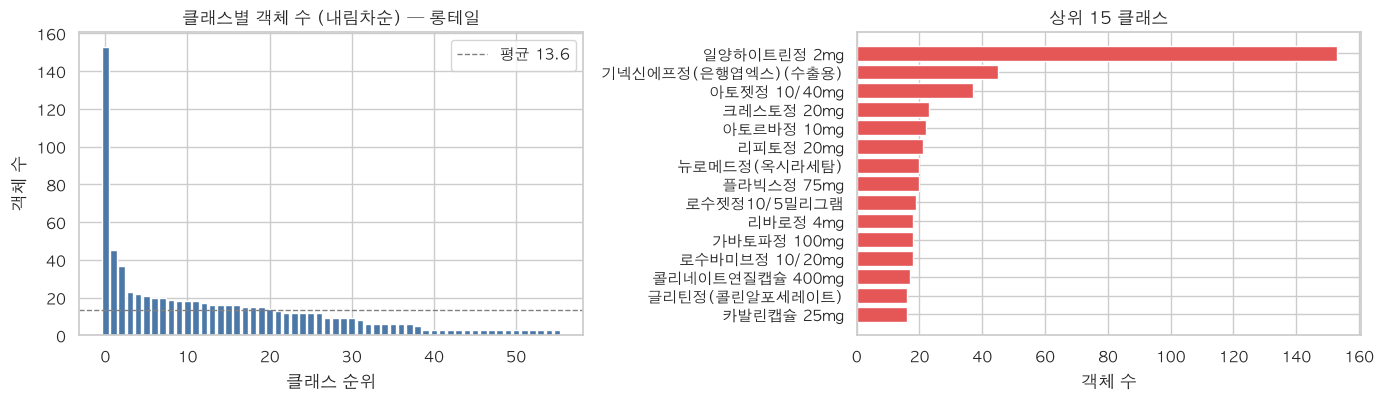

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].bar(range(len(c)), np.sort(c)[::-1], color="#4C78A8")
ax[0].set(title="클래스별 객체 수 (내림차순) — 롱테일", xlabel="클래스 순위", ylabel="객체 수")
ax[0].axhline(c.mean(), ls="--", c="gray", lw=1, label=f"평균 {c.mean():.1f}")
ax[0].legend()
top = cls_named.head(15)[::-1]
ax[1].barh(top.index, top.values, color="#E45756")
ax[1].set(title="상위 15 클래스", xlabel="객체 수")
plt.tight_layout(); plt.show()

### ② 약품 동시출현 (쌍 빈도 · 행렬)

In [5]:
from itertools import combinations
sets = ann.groupby("file_name").category_id.apply(lambda s: frozenset(s))

pair = Counter()
for s in sets:
    for a, b in combinations(sorted(s), 2):
        pair[(a, b)] += 1
print(f"동시 등장한 약품 쌍: 서로 다른 {len(pair)}쌍\n[가장 자주 함께 나온 쌍 top10]")
for (a, b), n in pair.most_common(10):
    print(f"  {n:3d}회  {cid2name[a]}  +  {cid2name[b]}")

동시 등장한 약품 쌍: 서로 다른 214쌍
[가장 자주 함께 나온 쌍 top10]
   21회  일양하이트린정 2mg  +  아토르바정 10mg
   20회  일양하이트린정 2mg  +  뉴로메드정(옥시라세탐)
   18회  일양하이트린정 2mg  +  아토젯정 10/40mg
   18회  기넥신에프정(은행엽엑스)(수출용)  +  아토젯정 10/40mg
   17회  일양하이트린정 2mg  +  크레스토정 20mg
   17회  일양하이트린정 2mg  +  로수바미브정 10/20mg
   17회  일양하이트린정 2mg  +  콜리네이트연질캡슐 400mg
   16회  일양하이트린정 2mg  +  리피로우정 20mg
   16회  일양하이트린정 2mg  +  마도파정
   16회  일양하이트린정 2mg  +  글리틴정(콜린알포세레이트)


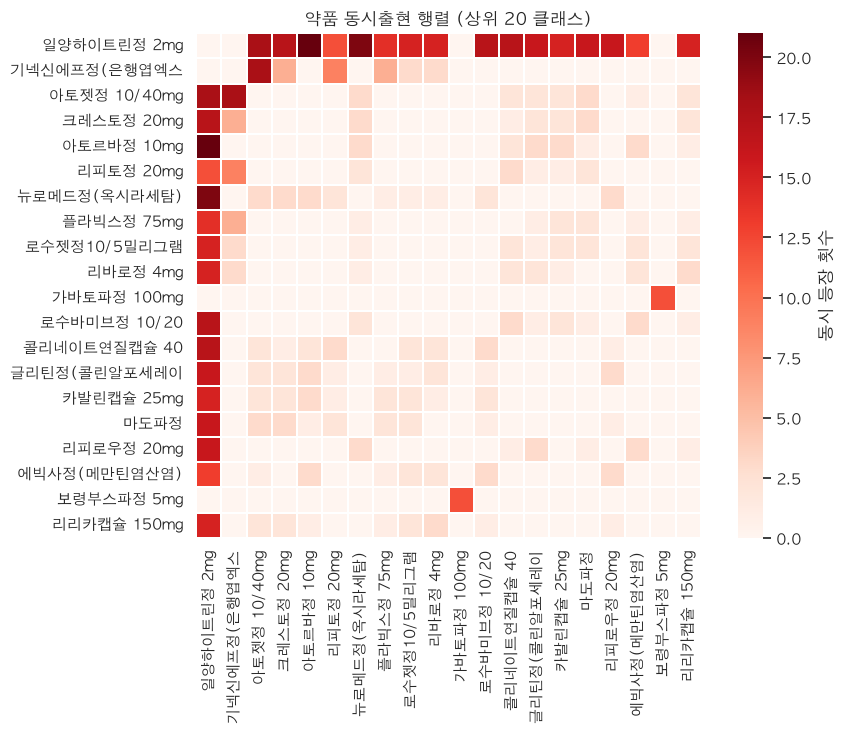

In [6]:
# 동시출현 행렬 — 가독성 위해 상위 20 빈출 클래스만
top_ids = cls_cnt.head(20).index.tolist()
tset = set(top_ids)
M = pd.DataFrame(0, index=top_ids, columns=top_ids)
for s in sets:
    inter = sorted(x for x in s if x in tset)
    for a, b in combinations(inter, 2):
        M.loc[a, b] += 1; M.loc[b, a] += 1
labels = [cid2name[i][:12] for i in top_ids]
plt.figure(figsize=(9.5, 7.5))
sns.heatmap(M.values, xticklabels=labels, yticklabels=labels, cmap="Reds",
            square=True, linewidths=.3, cbar_kws={"label": "동시 등장 횟수"})
plt.title("약품 동시출현 행렬 (상위 20 클래스)"); plt.tight_layout(); plt.show()

### ③ 조합의 구조성 (무작위 vs 반복)

In [7]:
combo_cnt = Counter(sets)                       # 정확히 같은 약품 세트의 빈도
img_per_combo = Counter(combo_cnt.values())
print(f"이미지 {sets.size}장 → 서로 다른 조합(세트) {len(combo_cnt)}개")
print(f"조합당 이미지 수 분포: {dict(sorted(img_per_combo.items()))}")
print(f"조합당 평균 이미지 = {sets.size/len(combo_cnt):.2f}")
# 조합 크기(약품 수) 분포
print("조합 크기(약품 수) 분포:", dict(sorted(Counter(len(s) for s in sets).items())))

이미지 232장 → 서로 다른 조합(세트) 122개
조합당 이미지 수 분포: {1: 50, 2: 34, 3: 38}
조합당 평균 이미지 = 1.90
조합 크기(약품 수) 분포: {2: 7, 3: 151, 4: 74}


> **§(b) 결론**
>
> **① 심한 롱테일 (H3 확정).** 최다 `일양하이트린정 2mg` 153개(**20.1%**), 최소 3개 → **불균형비 51배 · Gini 0.497 · 상위 5클래스가 36.7%**. **56클래스 중 48개가 객체<20, 29개가 <10, 17개가 <5** 로 대부분이 데이터 기아 상태. → ⓐ 리샘플링·손실 가중(focal 등)·표적 증강 필요, ⓑ **희소 17클래스는 천장 후보**(과투자 금지·정직히 보고), ⓒ **외부데이터(2)의 진짜 명분 = 커버리지가 아니라 클래스별 물량**(40⊆56라 커버는 되지만 표본이 너무 적음).
>
> **② 동시출현이 한 약에 쏠림 (H6 확정).** `일양하이트린정`이 232장 중 **약 153장(≈66%)** 에 등장하는 *허브 약* — 거의 모든 약과 함께 나와 상위 동시출현 쌍을 독식. 조합이 무작위가 아니다. → 모델이 **"이 약은 늘 있다"는 허위 편향**을 학습할 위험, test 조합 분포가 다르면 일반화 갭. (이 약이 test-40 소속인지 train 전용 디스트랙터인지는 40 비공개라 미상 → 주의 플래그.)
>
> **③ 조합은 반복·구조화.** 232장 → 조합 122개(조합당 평균 1.9장; 1회 50·2회 34·3회 38). 같은 조합을 각도만 바꿔 반복 촬영. → **동일 조합이 train/val로 갈리면 누수** → **분할은 조합(또는 이미지) 단위 그룹 K-Fold** 필수(리더보드 과신 방지, DR-06).
>
> **다음: (c) bbox 크기/위치/개수 분포 — 고-IoU 설계 근거 + 품질플래그 8장 확인.**

## 📐 (c) bbox 크기 · 위치 · 개수

**왜 보는가.** 고-IoU 지표(H2)에서는 박스 크기·위치 분포가 곧 설계 근거다. 알약이 화면에서 얼마나 크고 어디에 놓이는지가 **입력 해상도(E3: 640→1024)·스케일·후처리**를 좌우한다. 더불어 (b)에서 찾은 **품질플래그 8장**(파일명 약품 수 > 실제 bbox 수)을 실제 이미지로 확인한다.

**무엇을 보는가.** ① bbox 크기(면적·종횡비)·이미지 대비 상대 크기, ② 중심 위치 분포(중앙 편중 여부), ③ 이미지당 객체 수 + 품질플래그 8장 육안 확인.

### ① bbox 크기 · 종횡비 · 상대 크기

In [8]:
W, H = 976, 1280
arr = np.array(ann.bbox.tolist(), dtype=float)
b = pd.DataFrame(arr, columns=["x", "y", "w", "h"])
b["area"] = b.w * b.h
b["rel_area"] = b.area / (W * H)
b["aspect"] = b.w / b.h
b["side_px"] = np.sqrt(b.area)

def pct(s): return {q: round(float(s.quantile(q)), 2) for q in (0, .25, .5, .75, 1.0)}
print("bbox w(px):", pct(b.w))
print("bbox h(px):", pct(b.h))
print("종횡비 w/h :", pct(b.aspect))
print("상대 면적(% of image):", {k: f"{v*100:.1f}%" for k, v in pct(b.rel_area).items()})
print(f"박스 한 변 근사 side_px 중앙값 {b.side_px.median():.0f}px "
      f"(이미지 짧은변 {W}px 대비 {b.side_px.median()/W:.0%})")
print(f"입력 리사이즈 시 중앙값 박스 한 변 ≈ 640: {b.side_px.median()*640/H:.0f}px / 1024: {b.side_px.median()*1024/H:.0f}px")

bbox w(px): {0: 125.0, 0.25: 189.5, 0.5: 230.0, 0.75: 285.0, 1.0: 529.0}
bbox h(px): {0: 126.0, 0.25: 191.0, 0.5: 227.0, 0.75: 316.0, 1.0: 664.0}
종횡비 w/h : {0: 0.4, 0.25: 0.83, 0.5: 1.0, 0.75: 1.04, 1.0: 2.11}
상대 면적(% of image): {0: '2.0%', 0.25: '3.0%', 0.5: '4.0%', 0.75: '7.0%', 1.0: '22.0%'}
박스 한 변 근사 side_px 중앙값 232px (이미지 짧은변 976px 대비 24%)
입력 리사이즈 시 중앙값 박스 한 변 ≈ 640: 116px / 1024: 185px


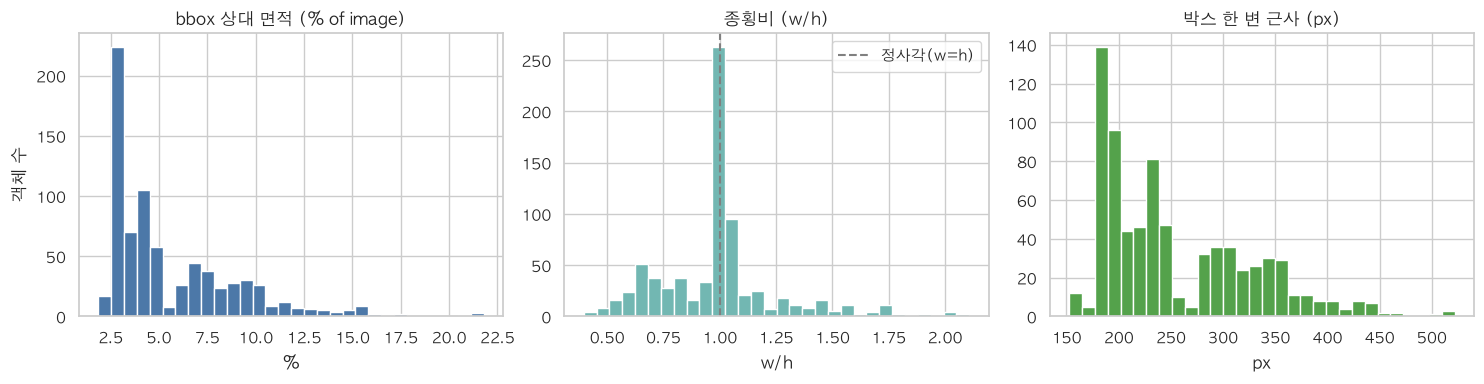

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(b.rel_area * 100, bins=30, color="#4C78A8"); ax[0].set(title="bbox 상대 면적 (% of image)", xlabel="%", ylabel="객체 수")
ax[1].hist(b.aspect, bins=30, color="#72B7B2"); ax[1].axvline(1, ls="--", c="gray", label="정사각(w=h)"); ax[1].legend(); ax[1].set(title="종횡비 (w/h)", xlabel="w/h")
ax[2].hist(b.side_px, bins=30, color="#54A24B"); ax[2].set(title="박스 한 변 근사 (px)", xlabel="px")
plt.tight_layout(); plt.show()

### ② 중심 위치 분포 (중앙 편중 여부)

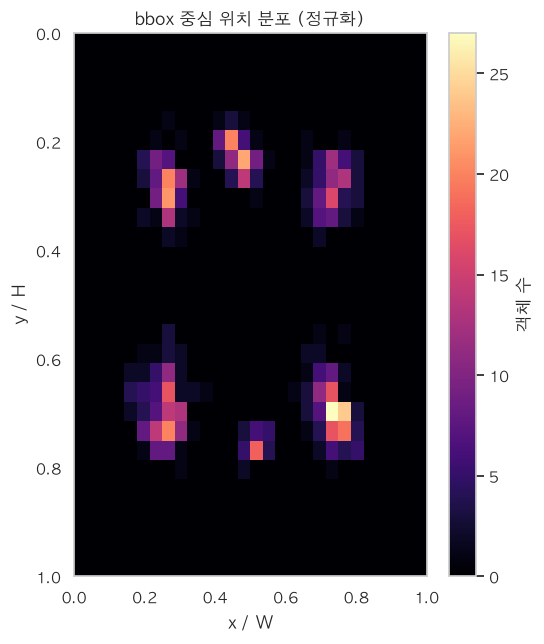

중심 x 중앙값 0.48 (IQR 0.27~0.73)
중심 y 중앙값 0.62 (IQR 0.27~0.71)


In [10]:
cx = (b.x + b.w / 2) / W
cy = (b.y + b.h / 2) / H
plt.figure(figsize=(5.6, 6.6))
plt.hist2d(cx, cy, bins=28, range=[[0, 1], [0, 1]], cmap="magma")
plt.gca().invert_yaxis(); plt.colorbar(label="객체 수")
plt.title("bbox 중심 위치 분포 (정규화)"); plt.xlabel("x / W"); plt.ylabel("y / H")
plt.tight_layout(); plt.show()
print(f"중심 x 중앙값 {cx.median():.2f} (IQR {cx.quantile(.25):.2f}~{cx.quantile(.75):.2f})")
print(f"중심 y 중앙값 {cy.median():.2f} (IQR {cy.quantile(.25):.2f}~{cy.quantile(.75):.2f})")

### ③ 이미지당 객체 수 + 품질플래그 8장 육안 확인

In [11]:
cnt = ann.groupby("file_name").size()
def ncodes(fn): return len([c for c in fn.split("_")[0].split("-")[1:] if c.isdigit()])
codes = cnt.index.to_series().apply(ncodes)
flagged = cnt.index[(codes.values != cnt.values)].tolist()
print("이미지당 객체 수:", dict(cnt.value_counts().sort_index()))
print(f"\n품질플래그 {len(flagged)}장 (파일명 약품 수 ≠ 실제 bbox 수):")
for fn in flagged:
    print(f"  codes={ncodes(fn)}  boxes={cnt[fn]}   {fn}")

이미지당 객체 수: {2: np.int64(7), 3: np.int64(151), 4: np.int64(74)}

품질플래그 8장 (파일명 약품 수 ≠ 실제 bbox 수):
  codes=3  boxes=2   K-003351-013900-021325_0_2_0_2_70_000_200.png
  codes=3  boxes=2   K-003351-013900-036637_0_2_0_2_70_000_200.png
  codes=3  boxes=2   K-003351-020014-022074_0_2_0_2_90_000_200.png
  codes=3  boxes=2   K-003351-021325-032310_0_2_0_2_90_000_200.png
  codes=3  boxes=2   K-003351-032310-038162_0_2_0_2_70_000_200.png
  codes=3  boxes=2   K-003351-033880-038162_0_2_0_2_75_000_200.png
  codes=3  boxes=2   K-003351-035206-041768_0_2_0_2_70_000_200.png
  codes=4  boxes=3   K-003544-004543-012247-016548_0_2_0_2_90_000_200.png


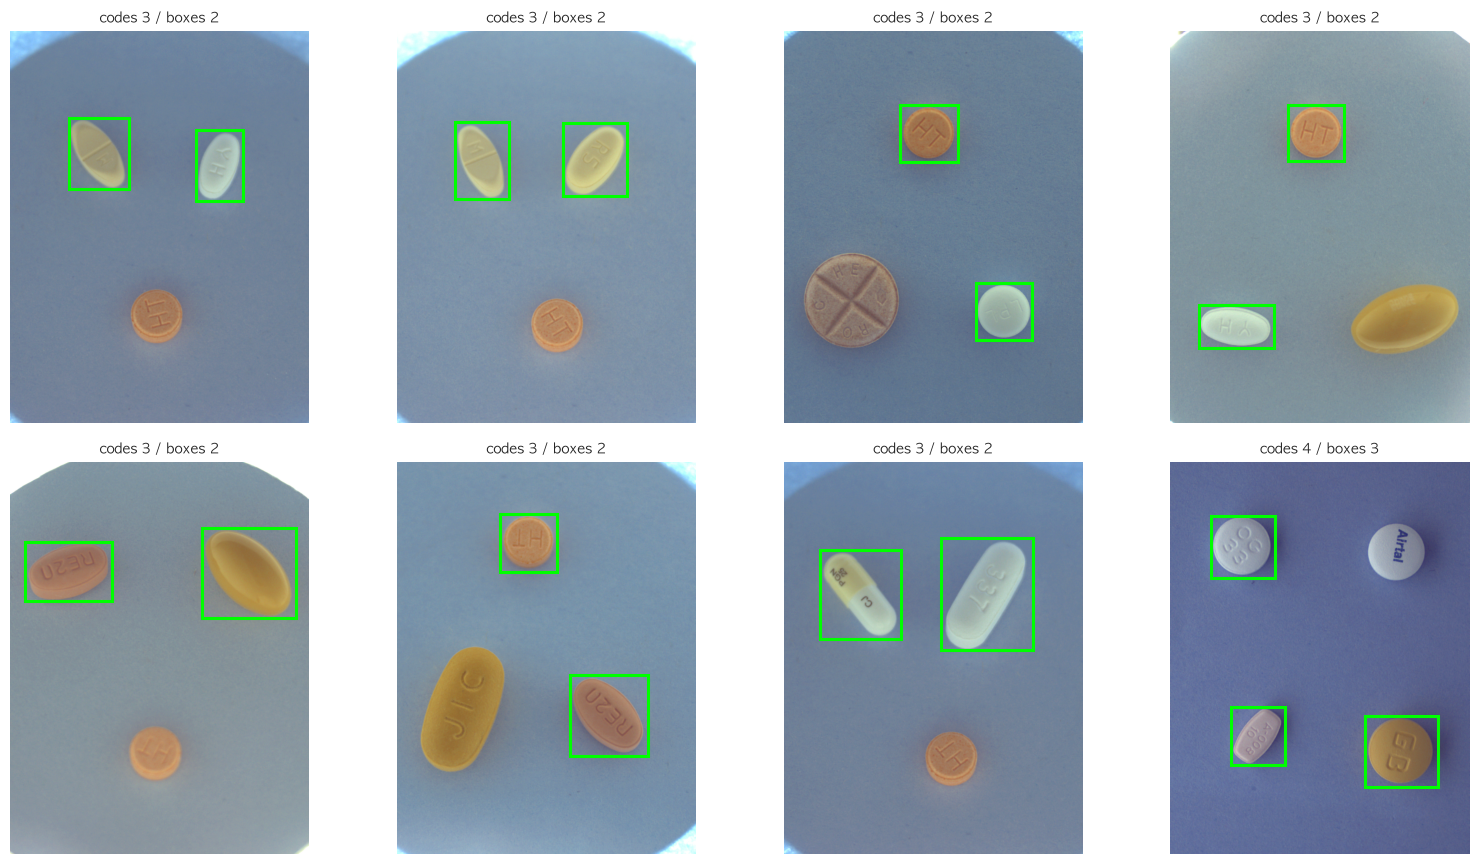

In [12]:
groups = {fn: g for fn, g in ann.groupby("file_name")}
n = len(flagged); cols = 4; rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4.4 * rows))
axes = np.array(axes).reshape(-1)
for i, fn in enumerate(flagged):
    ax = axes[i]; img = cv2.imread(str(TRAIN_IMG / fn))
    if img is None:
        ax.set_title("load fail"); ax.axis("off"); continue
    ax.imshow(img[:, :, ::-1])
    for _, r in groups[fn].iterrows():
        x, y, w, h = r.bbox
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, ec="lime", lw=2.2))
    ax.set_title(f"codes {ncodes(fn)} / boxes {cnt[fn]}", fontsize=10); ax.axis("off")
for j in range(n, len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.show()

> **§(c) 결론**
>
> **① 박스는 '중간 크기 + 배경 여백 큼'.** 상대 면적 중앙값 **4%**(IQR 3–7%, 최대 22%), 한 변 근사 **232px**(짧은변의 24%). 종횡비 중앙값 **1.0**이지만 0.4~2.11로 꼬리가 넓다(원형↔장방형 혼재 → **형태가 식별 단서**). → 리사이즈해도 640에서 한 변 ≈116px, 1024에서 ≈185px라 **검출 자체는 충분**. 즉 **고해상도(E3)의 가치는 '작은 물체 검출'이 아니라 '0.9 IoU급 엣지 정밀도'** — 고-IoU 지표(H2)와 정확히 맞물린다.
>
> **② 중심은 넓게 퍼짐(중앙 편중 약함).** 중심 x 중앙값 0.48(IQR 0.27–0.73), y 0.62(IQR 0.27–0.71) — 프레임 전반 분포, y가 약간 아래로 치우침. → 강한 공간 prior 없음 → **전면 특징 커버 필요**(중앙 크롭성 전처리는 주의).
>
> **③ 품질플래그 8장(3.4%) = 라벨 부족.** 전부 '약품 수보다 bbox 1개 적음'(7장 codes3→box2, 1장 codes4→box3). **8장 중 7장이 허브 약 `일양하이트린정(003351)` 포함** → 한 알이 미어노테이션/오클루전. 남은 박스는 정상이라 학습에 쓸 수 있으나, **미라벨 알약이 배경으로 취급돼 위양성 신호**가 됨 → 소규모지만 **HITL 보정 또는 제외 애블레이션** 후보. (위 그리드에서 겹침/누락 원인 육안 판별 가능.)
>
> **다음: (e) 배경·조명 메타 분포 — (1)↔(2) 도메인갭 예비(H4/H5).**

## 🎨 (e) 배경 · 조명 메타 (도메인갭 예비)

**왜 보는가.** 대회 앵커(1)의 **촬영조건 프로파일**(배경색·조명색·방향·카메라각)을 수치화해, 앞서 육안으로 본 **AI Hub 단일(2)** 과의 도메인갭을 가늠한다(H4 색 불안정 · H5 도메인갭). 색이 얼마나 불안정한지, (2)를 그대로 섞어도 되는지, 증강·정규화를 어디에 걸지가 여기서 갈린다.

**무엇을 보는가.** ① 배경색·조명색·알약방향 분포, ② 카메라 각도(위도/경도) 분포, ③ (1)↔(2) 대조 → 결론.

### ① 촬영조건 분포 (이미지 232장 단위)

In [13]:
# 이미지 단위 촬영 메타 (file_name 기준 dedup → 232장)
meta_rows = {}
for jf in ann_files:
    d = json.loads(jf.read_text(encoding="utf-8")); im = d["images"][0]
    fn = im["file_name"]
    meta_rows.setdefault(fn, dict(
        back_color=im.get("back_color"), light_color=im.get("light_color"),
        drug_dir=im.get("drug_dir"), camera_la=im.get("camera_la"),
        camera_lo=im.get("camera_lo"), drug_S=im.get("drug_S")))
meta = pd.DataFrame(list(meta_rows.values()))
print("이미지 메타 shape:", meta.shape)
for col in ["back_color", "light_color", "drug_dir", "camera_la", "camera_lo", "drug_S"]:
    vc = meta[col].value_counts(dropna=False)
    print(f"\n[{col}] 고유값 {meta[col].nunique(dropna=True)}개")
    print(vc.head(10).to_string())

이미지 메타 shape: (232, 6)

[back_color] 고유값 1개
back_color
연회색 배경    232

[light_color] 고유값 1개
light_color
주백색    232

[drug_dir] 고유값 2개
drug_dir
앞면    228
뒷면      4

[camera_la] 고유값 3개
camera_la
90    85
75    75
70    72

[camera_lo] 고유값 1개
camera_lo
0    232

[drug_S] 고유값 1개
drug_S
정상알약    232


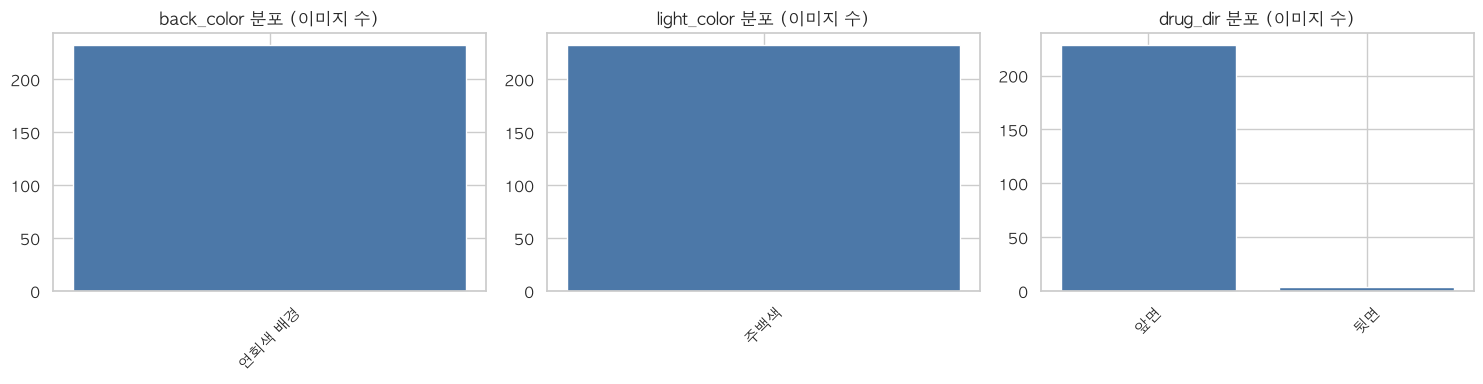

카메라 (la, lo) 조합 분포:
camera_la  camera_lo
90         0            85
75         0            75
70         0            72


In [14]:
cat_cols = ["back_color", "light_color", "drug_dir"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, cat_cols):
    vc = meta[col].astype(str).value_counts().head(10)
    a.bar(vc.index, vc.values, color="#4C78A8")
    a.set(title=f"{col} 분포 (이미지 수)"); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# 카메라 각도(위도×경도) 조합
print("카메라 (la, lo) 조합 분포:")
print(meta.groupby(["camera_la", "camera_lo"]).size().sort_values(ascending=False).head(10).to_string())

> **§(e) 결론 — 앵커 도메인은 '단일·통제', 이 사실이 전략을 바꾼다**
>
> **① (1)=테스트 도메인의 촬영조건은 사실상 하나다.** 배경색 **연회색 232/232(단일)**, 조명 **주백색 232/232(단일)**, 방향 앞면 228·뒷면 4, 카메라 위도 3종(70/75/90)·경도 0(단일), 상태 정상알약 단일. → **테스트는 '연회색 배경 + 주백색 조명 + 준탑다운 정면'이라는 좁고 균일한 조건**에서 촬영된다.
>
> **② (1)↔(2) 도메인갭이 크고, 방향이 예상과 반대다(H5 확정).** AI Hub 단일(2)은 배경·조명·WB가 극단적으로 다양(암↔명·다색). 즉 **앵커(1)는 좁고 (2)는 넓다.** → (2)의 원색 배경을 그대로 학습에 섞으면 **테스트에 없는 조건에 모델 용량을 낭비**해 대회 성능을 오히려 해칠 수 있다.
>
> **③ 그래서 (2) 사용법·증강·색 전략을 수정한다.**
> - **(2)는 (1) 도메인으로 정규화해서 사용:** 단일 알약을 잘라 **연회색 배경 + 주백색 톤**으로 WB 정규화 후 Copy-Paste 합성(대회용). (2)의 원배경은 버린다. *다양한 현실 배경 합성은 대회가 아니라 서비스 트랙용.*
> - **색은 (1) 안에선 오히려 신뢰 가능(H4 부분 반전):** 조명이 단일이라 `color_class`가 안정 → **대회에선 색을 식별 단서로 쓸 수 있다.** 단 (2)를 섞을 땐 WB 정규화가 전제(안 하면 색이 노이즈).
> - **증강은 앵커 근방으로 보수적:** 기하(면내 회전·플립·스케일) 위주, **광학/배경 랜덤화는 약하게**(테스트가 단일 조건). 강한 도메인 랜덤화는 서비스용.
> - 방향이 앞면 위주 → **각인(print_front)이 안정적으로 관측**(XAI·미세식별에 유리).
>
> → 이중트랙이 더 선명해짐: **대회 = 좁은 (1) 도메인에 정렬 / 서비스 = (2)의 다양성 수용.**

## 🧭 (f) EDA 종합 · 가설 갱신

(b)(c)(e)에서 확인한 사실을 **가설 검증 → 데이터 계약·실행 설계**로 묶는다. 이 절이 베이스라인(E1)과 이후 실험의 출발 규격이 된다.

### 가설 검증표 (H1~H6)

| 가설 | 결과 | 핵심 근거 | 함의 |
| --- | --- | --- | --- |
| **H1 저데이터** | ✅ 확정 | train 232장·763객체, 56클래스 중 48개가 객체<20 | 전이학습·증강·(2) 물량 보강 필수 |
| **H2 고-IoU→localization** | ✅ 확정(전제) | 박스 상대면적 중앙값 4%, 640서도 한 변 ≈116px(검출 충분) | 해상도 가치 = "작은물체"가 아니라 **엣지 정밀** → 1024·CIoU/DFL |
| **H3 불균형·천장** | ✅ 확정 | Gini 0.497, 불균형 51배, 객체<5 클래스 17개 | 리샘플·손실가중, **희소 17클래스=천장 후보**(과투자 금지) |
| **H4 색 불안정** | ⚠️ **부분 반전** | (2)는 WB 불안정하나 **(1)은 조명 주백색 단일→색 안정** | **대회 도메인선 색 사용 가능**, (2) 혼합 시 WB 정규화 전제 |
| **H5 (1)↔(2) 도메인갭** | ✅ 확정(방향 반대) | (1) 배경/조명 단일 ↔ (2) 배경·WB 광범위 | (2)를 **(1) 도메인으로 정규화**해 사용, 원색 배경 학습 지양 |
| **H6 조합 편향** | ✅ 확정 | 허브약 `003351`이 66% 등장, 조합 반복(232→122) | **조합 단위 Group K-Fold**(누수 방지), 허브약 편향 주의 |

### 검증: 조합 단위 Group K-Fold (누수·희소 클래스 확인)

같은 조합(약품 세트)을 각도만 바꿔 반복 촬영했으므로, 단순 무작위 분할은 **train/val 누수**를 만든다. 조합을 그룹으로 묶어 분할하고, 각 fold의 클래스 커버리지를 확인한다.

In [15]:
# 조합(frozenset) = 그룹. 의존성 없이 수동 Group K-Fold (sklearn은 학습 단계에서 도입)
img_names = sets.index.tolist()
combo_of = {c: i for i, c in enumerate(dict.fromkeys(sets.values))}
groups = np.array([combo_of[sets[fn]] for fn in img_names])
img_cls = {fn: set(g.category_id) for fn, g in ann.groupby("file_name")}

rng = np.random.default_rng(SEED)
uniq = np.array(sorted(set(groups))); rng.shuffle(uniq)
folds = np.array_split(uniq, 5)
g2fold = {g: k for k, fl in enumerate(folds) for g in fl}
img_fold = np.array([g2fold[g] for g in groups])

print(f"이미지 {len(img_names)}장 · 조합(그룹) {len(uniq)}개 → 5-fold\n")
for k in range(5):
    va = [i for i in range(len(img_names)) if img_fold[i] == k]
    tr = len(img_names) - len(va)
    va_cls = set().union(*[img_cls[img_names[i]] for i in va]) if va else set()
    print(f"fold{k}: train_img={tr:3d}  val_img={len(va):3d}  | val 클래스 {len(va_cls):2d}/56 (val 부재 {56-len(va_cls)}개)")
print("\n→ 같은 조합이 train/val로 쪼개지지 않음(누수 방지). 단 fold마다 희소 클래스가 val에서 빠져 per-class AP는 불안정.")

이미지 232장 · 조합(그룹) 122개 → 5-fold

fold0: train_img=181  val_img= 51  | val 클래스 32/56 (val 부재 24개)
fold1: train_img=185  val_img= 47  | val 클래스 35/56 (val 부재 21개)
fold2: train_img=184  val_img= 48  | val 클래스 31/56 (val 부재 25개)
fold3: train_img=194  val_img= 38  | val 클래스 29/56 (val 부재 27개)
fold4: train_img=184  val_img= 48  | val 클래스 28/56 (val 부재 28개)

→ 같은 조합이 train/val로 쪼개지지 않음(누수 방지). 단 fold마다 희소 클래스가 val에서 빠져 per-class AP는 불안정.


> **§(f) 종합 결론 — 데이터 계약 & 실행 설계**
>
> **데이터 계약**
> - **작업 클래스 공간 = train-56**(category_id = int(dl_idx)). 제출은 56로 예측, 채점은 40. `class_map`/`drug_master` 생성 완료(SSOT).
> - **검증 = 조합 단위 5-fold Group K-Fold**(위 실증: 동일 조합 누수 0). **단 각 fold val이 28~35/56 클래스만 포함(21~28개 부재)** → 단일 split 신뢰 불가 → **K-fold 집계로 판단**, per-class AP(특히 희소)는 참고만. 이 분할을 로컬 하니스 공용 기준으로.
> - **품질플래그 8장:** 유효 박스는 정상 → 일단 학습 포함, **제외 애블레이션**으로 미라벨 알약의 위양성 영향 측정.
> - **분리 원칙:** val/test는 (1)에서만. (2)(3)은 train 전용.
>
> **불균형 대응(H3)**
> - 클래스 균형 샘플러 + 손실 가중/focal. **희소 17클래스(<5)는 (2) 물량 보강 1순위**, 그래도 막히면 천장으로 정직 보고.
>
> **해상도·증강·색(H2/H4/H5)**
> - **입력 1024 지향**(엣지 정밀, E3), 박스 손실 **CIoU/DIoU + DFL**.
> - 증강은 **기하 위주 + 광학 보수적**(테스트 단일 조건). (2)는 **WB 정규화 + 연회색 배경 Copy-Paste**로만 대회 투입, 원색 배경 지양. 강한 도메인 랜덤화는 서비스 트랙.
> - (1) 내 색 안정 → **색을 식별 단서로 사용 가능**(모델·XAI 활용).
>
> **모델(docs/02 §5.2 연계)**
> - 안정적 색·형태·각인 → 미세분류·고-IoU에 **Cascade R-CNN/CNN이 강점**(per-ROI 분류 유리). P0는 YOLO(26/11)로 floor·서빙.
>
> **오픈 이슈**
> - Test-40 비공개 → 40⊄56(디스트랙터) 여부·per-class 평가 한계. 허브약 `003351` 편향(상시 존재 허위학습 위험). (2)/(3) 다운로드 대기.
>
> **다음 단계 후보:** ① E1 베이스라인(train-56·group-fold val·1024·보수 증강) 착수 / ② (2) 준비 후 WB 정규화·Copy-Paste 증강 파이프 / ③ 증강 정책·평가 하니스 상세 설계.